In [1]:
import os


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns

In [2]:
sns.set_style("whitegrid")

In [3]:
INPUT_DIR = "/n/groups/kirschner/Will/BedRest/deseq2"

galaxy_res = pd.read_csv(os.path.join(INPUT_DIR, "deseq2_results_galaxy.csv"))
kallisto_res = pd.read_csv(os.path.join(INPUT_DIR, "deseq2_results_kallisto_tmp_post_pre.csv"))
star_rsem_res = pd.read_csv(os.path.join(INPUT_DIR, "deseq2_results_star_rsem_tmp_post_pre.csv"))
paper_res = pd.read_excel(os.path.join(INPUT_DIR, "Whole cohort Bed Rest DESeq2 Analysis.xlsx"), sheet_name="Original DESeq2")

In [4]:
gene_id = "gene_id"

galaxy_res[gene_id] = galaxy_res.iloc[:,0].str.split(".", expand=True).iloc[:,0]
kallisto_res[gene_id] = kallisto_res.iloc[:,0].str.split(".", expand=True).iloc[:,0]
star_rsem_res[gene_id] = star_rsem_res.iloc[:,0].str.split(".", expand=True).iloc[:,0]
paper_res[gene_id] = paper_res["Gene Identifier"]

In [5]:
for res in [galaxy_res, kallisto_res, star_rsem_res, paper_res]:
    res["direct"] = 1
    res.loc[res.log2FoldChange < 0, "direct"] = -1

    res["-log(pval)"] = - np.log10(res.pvalue) * res.direct

    res.fillna({"-log(pval)": 0}, inplace=True)

### Kallisto vs STAR+RSEM

In [6]:
kallisto_star_rsem = kallisto_res.set_index(gene_id).join(star_rsem_res.set_index(gene_id), how="outer", lsuffix="_kallisto", rsuffix="_STAR_RSEM")

kallisto_star_rsem.fillna({"-log(pval)_kallisto": 0, "-log(pval)_STAR_RSEM": 0}, inplace=True)

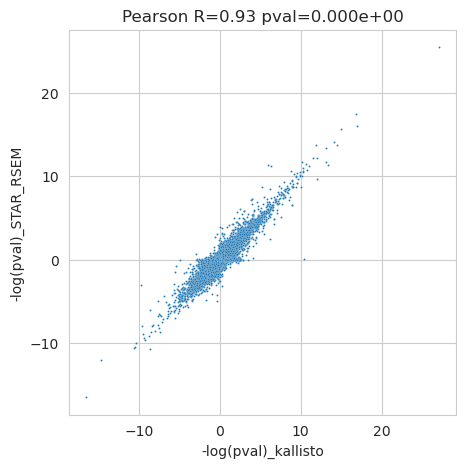

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))

r = scipy.stats.pearsonr(kallisto_star_rsem["-log(pval)_kallisto"], kallisto_star_rsem["-log(pval)_STAR_RSEM"])
sns.scatterplot(kallisto_star_rsem, x="-log(pval)_kallisto", y="-log(pval)_STAR_RSEM", ax=ax, s=2)
_ = plt.title(f"Pearson R={r.statistic:.2f} pval={r.pvalue:.3e}")

### Galaxy vs STAR+RSEM

In [8]:
galaxy_star_rsem = galaxy_res.set_index(gene_id).join(star_rsem_res.set_index(gene_id), how="outer", lsuffix="_galaxy", rsuffix="_STAR_RSEM")

galaxy_star_rsem.fillna({"-log(pval)_galaxy": 0, "-log(pval)_STAR_RSEM": 0}, inplace=True)

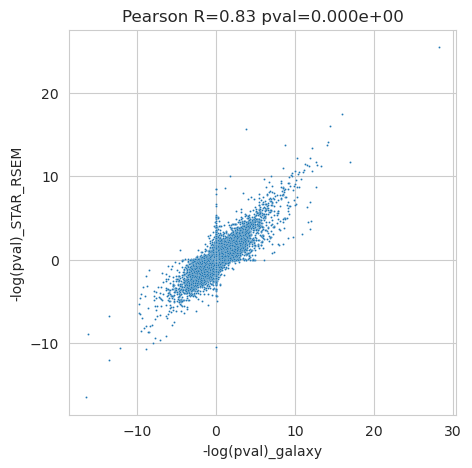

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))

r = scipy.stats.pearsonr(galaxy_star_rsem["-log(pval)_galaxy"], galaxy_star_rsem["-log(pval)_STAR_RSEM"])
sns.scatterplot(galaxy_star_rsem, x="-log(pval)_galaxy", y="-log(pval)_STAR_RSEM", ax=ax, s=2)
_ = plt.title(f"Pearson R={r.statistic:.2f} pval={r.pvalue:.3e}")

### Galaxy vs Kallisto

In [10]:
galaxy_kallisto = galaxy_res.set_index(gene_id).join(kallisto_res.set_index(gene_id), how="outer", lsuffix="_galaxy", rsuffix="_kallisto")

galaxy_kallisto.fillna({"-log(pval)_galaxy": 0, "-log(pval)_kallisto": 0}, inplace=True)

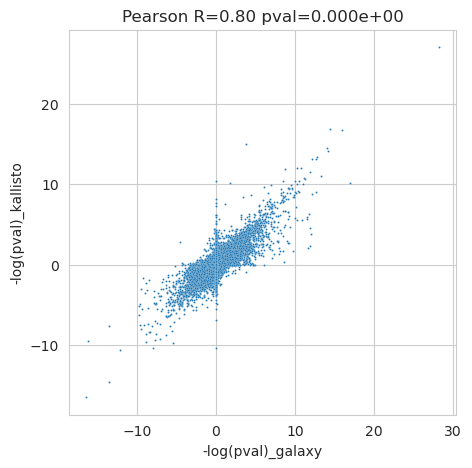

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))

r = scipy.stats.pearsonr(galaxy_kallisto["-log(pval)_galaxy"], galaxy_kallisto["-log(pval)_kallisto"])
sns.scatterplot(galaxy_kallisto, x="-log(pval)_galaxy", y="-log(pval)_kallisto", ax=ax, s=2)
_ = plt.title(f"Pearson R={r.statistic:.2f} pval={r.pvalue:.3e}")

### Paper vs Galaxy

In [12]:
galaxy_paper = galaxy_res.set_index(gene_id).join(paper_res.set_index(gene_id), how="outer", lsuffix="_galaxy", rsuffix="_paper")

galaxy_paper.fillna({"-log(pval)_galaxy": 0, "-log(pval)_paper": 0}, inplace=True)

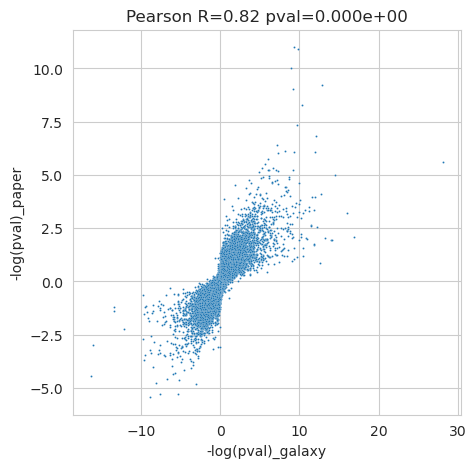

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))

r = scipy.stats.pearsonr(galaxy_paper["-log(pval)_galaxy"], galaxy_paper["-log(pval)_paper"])
sns.scatterplot(galaxy_paper, x="-log(pval)_galaxy", y="-log(pval)_paper", ax=ax, s=2)
_ = plt.title(f"Pearson R={r.statistic:.2f} pval={r.pvalue:.3e}")

### Paper vs STAR_RSEM

In [18]:
paper_star_rsem = paper_res.set_index(gene_id).join(star_rsem_res.set_index(gene_id), how="outer", lsuffix="_paper", rsuffix="_star_rsem")

paper_star_rsem.fillna({"-log(pval)_paper": 0, "-log(pval)_star_rsem": 0}, inplace=True)

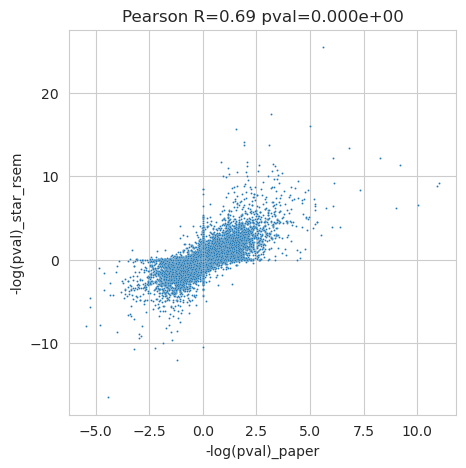

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))

r = scipy.stats.pearsonr(paper_star_rsem["-log(pval)_paper"], paper_star_rsem["-log(pval)_star_rsem"])
sns.scatterplot(paper_star_rsem, x="-log(pval)_paper", y="-log(pval)_star_rsem", ax=ax, s=2)
_ = plt.title(f"Pearson R={r.statistic:.2f} pval={r.pvalue:.3e}")